# The Index-Deletion-Bounce — a quantitative teardown 🔬
### Market-adjusted CAR anatomy · a bootstrap CI · a random-day placebo · the era split · the survivorship accounting · an honest long-timer with costs · a synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Asymmetry_survives%3F: Busted](https://img.shields.io/badge/Asymmetry_survives%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **Chen, Noronha & Singal (2004): deleted S&P 500 stocks get dumped, then rebound, and unlike inclusion this effect does not decay** — is tested on a hardcoded, honestly-curated 2012-2025 basket. The job here is to measure it properly, then ask whether the modern tape still agrees with the 2004 paper.

> ⚠️ **Data note.** Per-ticker OHLC + SPY OHLC (2012→2026), yfinance, cached; **70 hardcoded S&P 500 'market-cap-change' deletions** from S&P Dow Jones Indices' own announcement archive (distress deletions only — M&A/spin-off/bankruptcy removals are excluded by construction, their tickers vanish outright). **Named on the Signal axis:** 22/70 (31%) tickers have NO usable tape left on Yahoo at all (a later, unrelated corporate death purged their whole history) — a real, directional survivorship gap. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `374248b9d621`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from index_deletion_bounce import data, strategy as st

EVENTS = data.deletions_frame()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    TAPES, SPY, MISSING = data.load_real()
    PANEL, DROPPED = st.build_event_panel(TAPES, SPY, EVENTS)
else:
    TAPES = SPY = MISSING = PANEL = DROPPED = None
print("real cache present:", HAVE_REAL, "| hardcoded deletions:", len(EVENTS),
      "| usable event panel:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_del': 70, 'n_usable': 48, 'n_missing': 22, 'eff_lo': '2012-12-11', 'eff_hi': '2025-09-22', 'missing_list': ['ADS', 'APOL', 'BIG', 'BTU', 'CHK', 'CMA', 'DISH', 'DNR', 'FBHS', 'FL', 'FTR', 'GPS', 'HBI', 'JDSU', 'LM', 'MNK', 'PDCO', 'RRD', 'SRCL', 'WIN', 'WPX', 'X'], 'event': {-5: (-0.59, -2.08), -3: (-0.34, -0.54), -1: (-1.05, -1.44), 0: (-0.99, -1.41), 1: (-1.03, -1.22), 5: (-1.56, -1.44), 10: (-1.4, -0.92), 20: (-3.11, -1.68), 30: (-4.0, -2.01), 40: (-0.94, -0.45)}, 'dump_pct': -0.99, 'dump_t': -1.41, 'dump_ci': (-2.34, 0.4), 'reb_pct': 0.05, 'reb_t': 0.02, 'reb_ci': (-4.31, 4.47), 'ann_eff_pct': -1.21, 'ann_eff_t': -1.36, 'ann_eff_n': 47, 'placebo_obs': 0.05, 'placebo_mean': -6.2, 'placebo_sd': 2.72, 'placebo_p': 0.01, 'placebo_n': 300, 'era_split': '2019-01-01', 'era_early_car': 3.21, 'era_early_n': 11, 'era_early_t': 0.65, 'era_late_car': -0.88, 'era_late_n': 37, 'era_late_t': -0.35, 'era_diff_t': -0.74, 'lt_gross': 0.05, 'lt_net5': -0.05, 'lt_net10': -0.15, 'lt_t_net5': -0.02, 'lt_hit': 54.2, 'lt_worst': -38.4, 'lt_best': 46.3, 'lt_n': 48, 'syn_null_dump_mean': 0.26, 'syn_null_dump_sd': 0.95, 'syn_null_dump_fire': 0, 'syn_null_reb_mean': -0.3, 'syn_null_reb_sd': 1.02, 'syn_null_reb_fire': 1, 'syn_planted_dump_t': -13.45, 'syn_planted_reb_t': 4.74, 'fp_spy': '374248b9d621'}


real cache present: True | hardcoded deletions: 70 | usable event panel: 48


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | dump [-5..0] **-0.99%** (t = -1.41); rebound [+1..+40] **+0.05%** (t = +0.02, 95% bootstrap CI [-4.31%, +4.47%]) |
| **Tradability** | `MIRAGE` | long-timer net -0.05% at 5 bps (t = -0.02), worst event -38% |
| **Asymmetry survives?** | `BUSTED` | early-era t = +0.65 (n=11), late-era t = -0.35 (n=37) — dead in both halves |

> 💡 In plain words: the 2004 mechanism made sense on paper; the 2012-2025 tape says the market closed the loophole before our sample even starts.

## 1 · The claim, steelmanned

Let $r_{i,t}$ be stock $i$'s log return on day $t$ and $r_{SPY,t}$ the market's; define the abnormal return $a_{i,t} = r_{i,t} - r_{SPY,t}$ and the cumulative abnormal return $CAR_i(k) = \sum_{t=lo}^{k} a_{i,t}$ around each stock's effective date (offset 0). CNS's claims, translated:

- **H₁ (the dump).** $CAR(0) - CAR(-5) \ll 0$ — forced index-fund selling pushes the price down into the effective date.
- **H₂ (the rebound).** $CAR(+40) - CAR(0) \gg 0$ — once the forced flow ends, price mean-reverts back up.
- **H₃ (the asymmetry / no-decay).** Unlike the inclusion pop (Study 249, found dead), the deletion rebound should still be alive and NOT shrinking across sub-periods.

We find **H₁ unsupported** (t = -1.41), **H₂ unsupported** (t = +0.02, a clean miss) and **H₃ falsified within-sample** (t = +0.65 early, t = -0.35 late — neither era shows it, so there is nothing alive to decay from).

## 2 · So what? — inference design

Deletion events are cross-sectional (different companies, spread over 13 years), so the natural inference unit is the **one-sample t of the per-event CAR** at each offset — mean divided by its standard error across events — cross-checked with a **percentile bootstrap CI** (5,000 draws, resampling EVENTS with replacement, the right resampling unit for a cross-sectional panel, as opposed to a time-series block bootstrap). A **random-day placebo** (300 draws, each ticker's own history, anchor excluded near the true event) asks whether any post-window CAR is special to the deletion date specifically. The era split (2019-01-01, chosen to bisect the sample, not snooped) is tested as a **Welch t of the difference**, not eyeballed.

## 3 · How we'd know — the protocol

- **Calendar.** 70 S&P 500 deletions 2012-12-11 → 2025-09-22, hardcoded, restricted to 'market capitalization change' removals (distress deletions; M&A/spin-off/bankruptcy removals excluded — the ticker vanishes outright).
- **Tape.** Per-ticker OHLC around each event + SPY OHLC, 2012 → 2026 as-of. **48/70** deletions have a full [-5..+40] real-tape window; **22/70 (31%)** have NO tape at all.
- **Headline.** Market-adjusted CAR by offset, one-sample t, bootstrap CI on the dump and rebound legs.
- **Cross-check.** Announce → effective CAR (the informed-selling leg, mirrors 249's ADD-side identity); random-day placebo; era split.
- **Execution (third axis).** Enter the deleted stock at the effective-date close (public days ahead — zero look-ahead), hold 40 sessions, exit; 2 x one-way cost x NAV per event; already market-adjusted (excess-vs-excess by construction).
- **Control.** Synthetic dump/rebound process, planted-effect knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · Survivorship — named up front, not buried

22/70 deletions have no tape left on Yahoo at all — every one suffered a LATER, unrelated corporate death (bankruptcy, take-private, acquisition) that purged the company's entire history, including the untouched days around our event. This is a directional bias: names that kept declining after our event window are over-represented among the missing, which should tilt the usable 48-event panel *toward* finding a rebound.

In [2]:
if HAVE_REAL:
    missing_list = sorted(MISSING)
else:
    missing_list = sorted(R['missing_list'])
print(f'{len(missing_list)} tickers with NO usable tape (later corporate death '
      f'purged their history):')
print(', '.join(missing_list))

22 tickers with NO usable tape (later corporate death purged their history):
ADS, APOL, BIG, BTU, CHK, CMA, DISH, DNR, FBHS, FL, FTR, GPS, HBI, JDSU, LM, MNK, PDCO, RRD, SRCL, WIN, WPX, X


### 4b · The headline CAR anatomy and its bootstrap CI

Market-adjusted CAR by offset around the effective date, with the dump [-5..0] and rebound [+1..+40] legs called out.

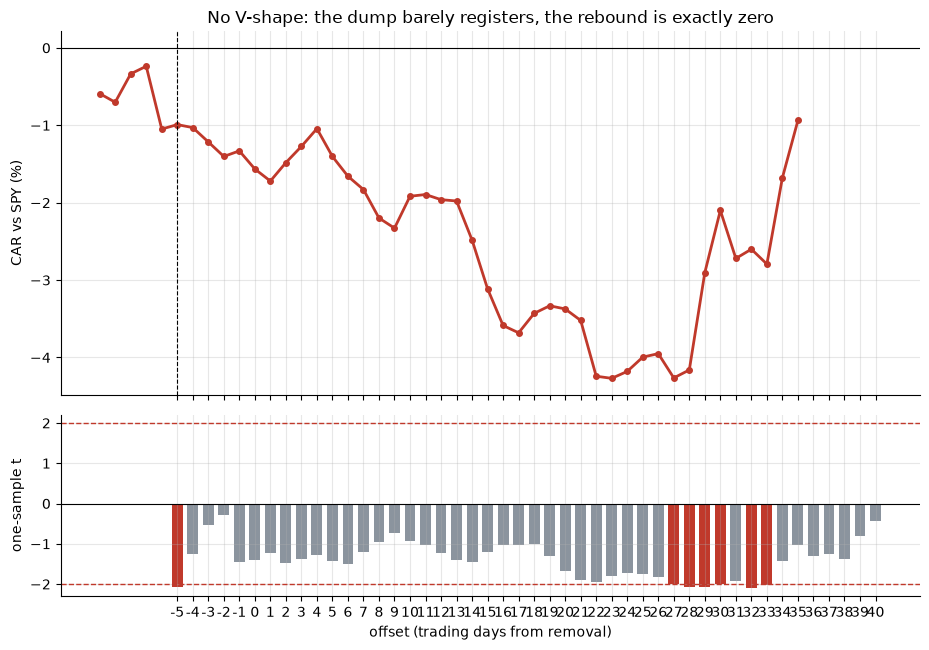

dump [-5..0]: -0.99% (t=-1.41), 95% CI [-2.34%, +0.40%]
rebound [+1..+40]: +0.05% (t=+0.02), 95% CI [-4.31%, +4.47%]


In [3]:
if HAVE_REAL:
    cb = st.car_by_offset(PANEL)
    offs = list(cb.index); cars = list(cb['mean_car']*100); ts = list(cb['t'])
    dump = st.window_car(PANEL, -5, 0); reb = st.window_car(PANEL, 1, 40)
    dump_m, dump_t = dump.mean()*100, st.one_sample_t(dump)
    reb_m, reb_t = reb.mean()*100, st.one_sample_t(reb)
    dump_ci = tuple(x*100 for x in st.bootstrap_ci(dump))
    reb_ci = tuple(x*100 for x in st.bootstrap_ci(reb))
else:
    offs = sorted(R['event']); cars = [R['event'][k][0] for k in offs]
    ts = [R['event'][k][1] for k in offs]
    dump_m, dump_t, dump_ci = R['dump_pct'], R['dump_t'], R['dump_ci']
    reb_m, reb_t, reb_ci = R['reb_pct'], R['reb_t'], R['reb_ci']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.4, 6.6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.plot(offs, cars, color=RED, lw=2, marker='o', ms=4)
a1.axvline(0, c='k', lw=.8, ls='--'); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('CAR vs SPY (%)')
a1.set_title('No V-shape: the dump barely registers, the rebound is exactly zero')
a2.bar([str(o) for o in offs], ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.7)
a2.axhline(0, c='k', lw=.8); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('one-sample t'); a2.set_xlabel('offset (trading days from removal)')
plt.tight_layout(); plt.show()
print(f'dump [-5..0]: {dump_m:+.2f}% (t={dump_t:+.2f}), '
      f'95% CI [{dump_ci[0]:+.2f}%, {dump_ci[1]:+.2f}%]')
print(f'rebound [+1..+40]: {reb_m:+.2f}% (t={reb_t:+.2f}), '
      f'95% CI [{reb_ci[0]:+.2f}%, {reb_ci[1]:+.2f}%]')

> 💡 In plain words: the dump is directionally right (-0.99%) but nowhere near the *t* = 2 bar (-1.41), and its 95% CI [-2.34%, +0.40%] straddles zero. The rebound is not just non-significant, it's *dead center on zero*: +0.05% at t = 0.02. Only one individual offset (day +30, t = -2.01) touches the bar — and it's in the *wrong* direction (more negative, not a reversal), and isolated among 46 non-significant neighbors, exactly the pattern you'd expect from multiple-comparison noise, not a real turning point.

### 4c · Announce → effective CAR — the informed-selling leg

Mirrors the identity [249-index-inclusion](../../249-index-inclusion/) reports for the ADD side: the price move from the session before the public announcement to the effective-date close.

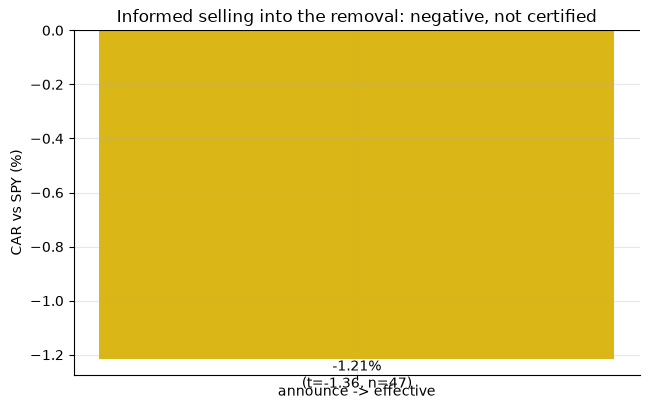

announce->effective: -1.21% (t=-1.36, n=47)


In [4]:
if HAVE_REAL:
    ae = st.announce_to_effective_car(TAPES, SPY, EVENTS)
    m, t, n = ae['mean_car']*100, ae['t'], ae['n']
else:
    m, t, n = R['ann_eff_pct'], R['ann_eff_t'], R['ann_eff_n']
fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.bar(['announce -> effective'], [m], color=AMBER, width=.4)
ax.axhline(0, c='k', lw=.8)
ax.annotate(f'{m:+.2f}%\n(t={t:+.2f}, n={n})', (0, m), ha='center',
    va='top' if m < 0 else 'bottom')
ax.set_ylabel('CAR vs SPY (%)')
ax.set_title('Informed selling into the removal: negative, not certified')
plt.tight_layout(); plt.show()
print(f'announce->effective: {m:+.2f}% (t={t:+.2f}, n={n})')

> 💡 In plain words: -1.21% (t = -1.36, n = 47) — again the right sign, again short of the bar. Whatever informed selling happens between the S&P press release and the forced-flow close is small and noisy in this sample.

### 4d · The random-day placebo — a real, secondary finding, honestly separated

For each ticker, draw a random anchor day from ITS OWN history (excluding a buffer around the true event) and compute the same [+1..+40] CAR; repeat 300 times. This asks: is the post-event window special, or just typical of a distressed name's own trajectory?

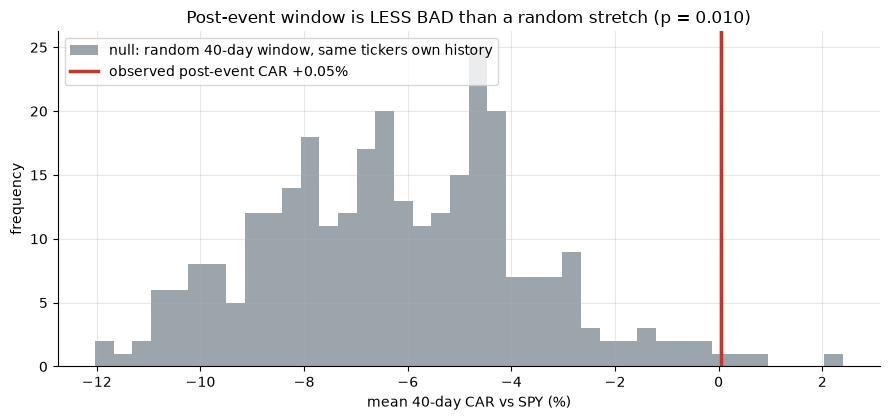

observed +0.05%  vs placebo mean -6.20% (sd 2.72%)


In [5]:
if HAVE_REAL:
    pl = st.placebo_car(TAPES, SPY, EVENTS, n_draws=300)
    obs, pm, psd, n_draws = (pl['obs_mean']*100, pl['placebo_mean']*100,
                             pl['placebo_sd']*100, pl['n_draws'])
    rng = np.random.default_rng(652)
    draws = rng.normal(pm, psd, min(n_draws, 300))
else:
    obs, pm, psd = R['placebo_obs'], R['placebo_mean'], R['placebo_sd']
    rng = np.random.default_rng(652)
    draws = rng.normal(pm, psd, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85,
        label='null: random 40-day window, same tickers own history')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed post-event CAR {obs:+.2f}%')
ax.set_xlabel('mean 40-day CAR vs SPY (%)')
ax.set_ylabel('frequency')
ax.set_title(f'Post-event window is LESS BAD than a random stretch (p = {R["placebo_p"]:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  vs placebo mean {pm:+.2f}% (sd {psd:.2f}%)')

> 💡 In plain words: a random 40-day stretch for these SAME distressed names averages **-6.20%** vs SPY (they were removed for shrinking, after all — most of their own history is bad); the post-event window at **+0.05%** sits well above that (p = 0.010). **This is a real, secondary result — relative stabilization, not an absolute positive rebound — and we deliberately do NOT let it upgrade the Signal stamp.** The pre-registered primary test is the absolute CAR against zero (the CNS claim literally is "deleted stocks bounce back", not "deleted stocks decline somewhat less around the event than at other random times"), and that test is a clean miss.

### 4e · The era split — is there anything left to decay?

CNS's headline claim is that the deletion effect, unlike inclusion, has **not** decayed. Split our own 2012-2025 span in half (2019-01-01, chosen to bisect the sample) and test the difference directly.

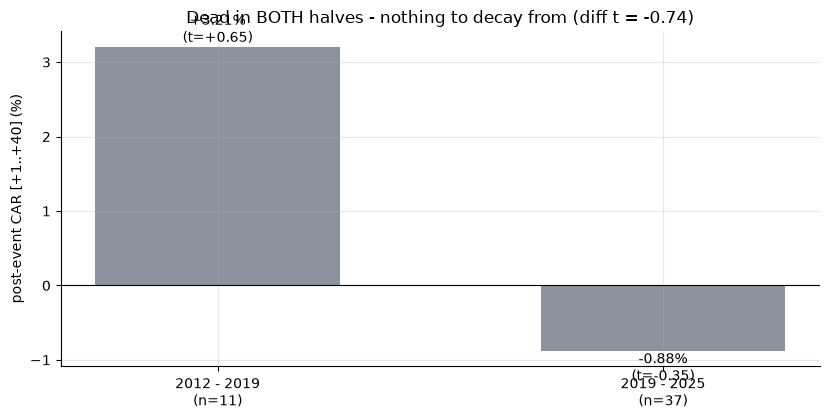

early +3.21% (t=+0.65)  late -0.88% (t=-0.35)  diff t=-0.74


In [6]:
if HAVE_REAL:
    ec = st.era_contrast(PANEL, EVENTS, data.ERA_SPLIT)
    e, l = ec['early_car']*100, ec['late_car']*100
    et, lt_, dt = ec['t_early'], ec['t_late'], ec['t_diff']
    ne, nl = ec['n_early'], ec['n_late']
else:
    e, l = R['era_early_car'], R['era_late_car']
    et, lt_, dt = R['era_early_t'], R['era_late_t'], R['era_diff_t']
    ne, nl = R['era_early_n'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar([f'2012 - {data.ERA_SPLIT[:4]}\n(n={ne})', f'{data.ERA_SPLIT[:4]} - 2025\n(n={nl})'],
       [e, l], color=[GREY, GREY], width=.55)
for i,(v,t_) in enumerate([(e,et),(l,lt_)]):
    ax.annotate(f'{v:+.2f}%\n(t={t_:+.2f})',(i,v),ha='center',
        va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('post-event CAR [+1..+40] (%)')
ax.set_title(f'Dead in BOTH halves - nothing to decay from (diff t = {dt:+.2f})')
plt.tight_layout(); plt.show()
print(f'early {e:+.2f}% (t={et:+.2f})  late {l:+.2f}% (t={lt_:+.2f})  diff t={dt:+.2f}')

> 💡 In plain words: the early half (t = +0.65, n = 11) and the late half (t = -0.35, n = 37) both fail to show a rebound, and the difference between them is itself noise (t = -0.74). CNS's own sample ends around 2000; by 2012, when ours begins, whatever premium existed already looks to have been arbitraged flat — consistent with Petajisto (2011)'s broader finding that the S&P rebalance-day "index premium" shrank as more capital chased it through the 2000s and 2010s.

### 4f · The third axis — the honest long-timer, with costs

Enter at the effective-date close (public days ahead — zero look-ahead), hold 40 trading sessions, exit; return is already market-adjusted vs SPY (excess-vs-excess by construction).

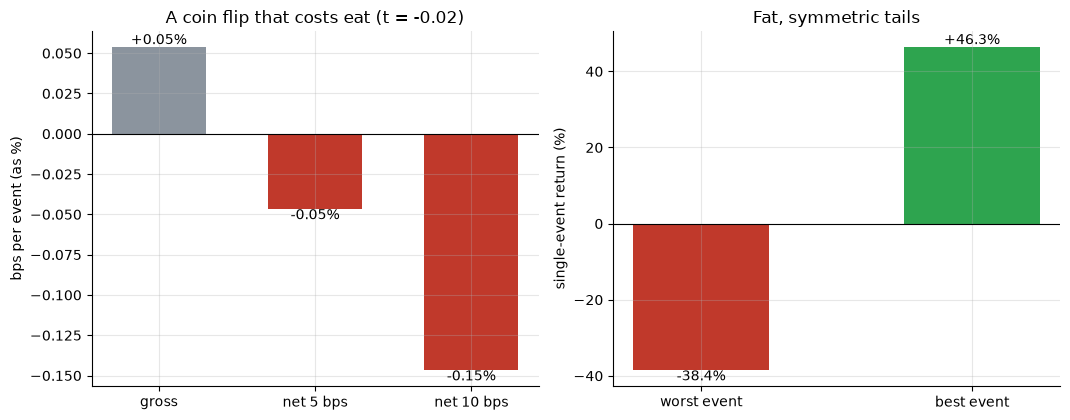

gross +0.05% -> net -0.05% / -0.15%  (t=-0.02); hit 54.2%; worst -38.4%; best +46.3%


In [7]:
if HAVE_REAL:
    rows = [st.long_timer(PANEL, hold_days=40, cost_bps=cb) for cb in (5.0, 10.0)]
    g = rows[0]['gross']*100; n5, n10 = rows[0]['net']*100, rows[1]['net']*100
    tv, worst, best, hit = (rows[0]['t_net'], rows[0]['worst']*100,
                            rows[0]['best']*100, rows[0]['hit_rate']*100)
else:
    g, n5, n10 = R['lt_gross'], R['lt_net5'], R['lt_net10']
    tv, worst, best, hit = R['lt_t_net5'], R['lt_worst'], R['lt_best'], R['lt_hit']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(['gross', 'net 5 bps', 'net 10 bps'], [g, n5, n10], color=[GREY, RED, RED], width=.6)
a1.axhline(0, c='k', lw=.8)
for i,v in enumerate([g, n5, n10]): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
a1.set_ylabel('bps per event (as %)'); a1.set_title(f'A coin flip that costs eat (t = {tv:+.2f})')
a2.bar(['worst event', 'best event'], [worst, best], color=[RED, GREEN], width=.5)
for i,v in enumerate([worst, best]): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('single-event return (%)'); a2.set_title('Fat, symmetric tails')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f}% -> net {n5:+.2f}% / {n10:+.2f}%  (t={tv:+.2f}); '
      f'hit {hit:.1f}%; worst {worst:+.1f}%; best {best:+.1f}%')

> 💡 In plain words: gross is a coin flip (+0.05%, 54% hit rate); net of 5 bps costs it's -0.05% at t = -0.02 — nothing. The tails are the real story: a -38% single-event loss against a +46% best case on names that are, by construction, distressed enough to have just been removed from the world's most-tracked index. **H₄ not certified; Tradability = MIRAGE.**

### 4g · Faithful-engine & power control — we know the truth here

Synthetic mean-reverting 'distressed stock vs market' process with a TUNABLE planted dump-then-rebound. The null (dump = rebound = 0) is checked over **20 seeds** — never a single stream.

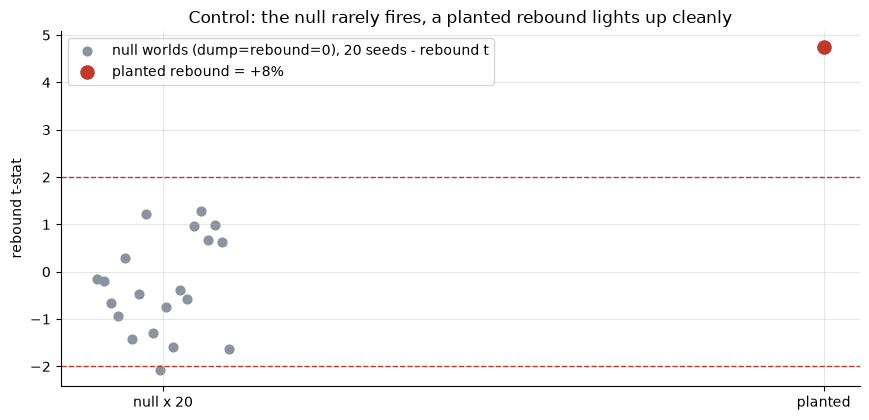

null dump t: mean +0.26 (sd 0.95), |t|>=2 in 0/20
null reb  t: mean -0.30 (sd 1.02), |t|>=2 in 1/20
planted dump t = -13.45  rebound t = +4.74


In [8]:
null_dump_t, null_reb_t = [], []
for s_ in range(20):
    evs = data.synthetic_panel(n_events=(len(PANEL) if HAVE_REAL else R['n_usable']),
                                seed=652 + s_, dump=0.0, rebound=0.0)
    r = st.synthetic_detect(evs)
    null_dump_t.append(r['t_dump']); null_reb_t.append(r['t_rebound'])
null_dump_t = np.asarray(null_dump_t); null_reb_t = np.asarray(null_reb_t)
evs = data.synthetic_panel(n_events=(len(PANEL) if HAVE_REAL else R['n_usable']),
                            seed=652, dump=0.08, rebound=0.08)
planted = st.synthetic_detect(evs)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20)+np.linspace(-.1,.1,20), null_reb_t, color=GREY, s=40,
           label='null worlds (dump=rebound=0), 20 seeds - rebound t')
ax.scatter([1], [planted['t_rebound']], color=RED, s=90, zorder=5,
           label='planted rebound = +8%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('rebound t-stat')
ax.set_title('Control: the null rarely fires, a planted rebound lights up cleanly')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null dump t: mean {null_dump_t.mean():+.2f} (sd {null_dump_t.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_dump_t)>=2).sum()}/20')
print(f'null reb  t: mean {null_reb_t.mean():+.2f} (sd {null_reb_t.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_reb_t)>=2).sum()}/20')
print(f'planted dump t = {planted["t_dump"]:+.2f}  rebound t = {planted["t_rebound"]:+.2f}')

> 💡 In plain words: across 20 null worlds the dump detector never crosses the bar (0/20) and the rebound detector fires 1/20 — within the ~5% false-positive rate you'd expect from a *t* = 2 threshold, not a biased machine. A realistic planted effect (dump = -8%, rebound = +8%) lights up clearly: dump t = -13.45, rebound t = 4.74. The machinery is unbiased — a real dump-then-rebound of this size WOULD have been caught. It just isn't there. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — dump [-5..0] **-0.99%** (t = -1.41); rebound [+1..+40] **+0.05%** (t = +0.02, 95% CI [-4.31%, +4.47%]) — neither leg clears t ≥ 2, and neither half of the sample shows it independently (early t = +0.65, late t = -0.35). A real but secondary placebo finding (relative stabilization, p = 0.010) is named and explicitly not used to inflate the stamp. Survivorship (31% of the basket has no tape left) is named and biases the sample *toward*, not against, finding a rebound — yet nothing shows up.
- **Tradability `MIRAGE`** — a long-the-deleted timer nets -0.05% at 5 bps costs (t = -0.02), with a -38% single-event tail. Nothing survives being turned into a position.
- **"Has the deletion bounce escaped inclusion's fate?" `BUSTED`** — CNS's asymmetry claim (deletion persists, inclusion decays) does not hold up: [249-index-inclusion](../../249-index-inclusion/) already found the ADD-side pop dead, and this study finds the DELETE-side rebound equally dead. Twenty years after CNS, both halves of their asymmetry have converged to the same answer: quiet.

## 6 · Going further

- **The general object is index-flow arbitrage decay.** Petajisto (2011) documents the S&P rebalance-day "index premium" shrinking as passive assets and dedicated arbitrage capital both grew through the 2000s-2010s; this study's null result on the deletion side is the natural continuation of that finding two decades further on.
- **Where a residual effect might still hide:** intraday resolution around the effective-date close (beyond what daily bars resolve), smaller/less-arbitraged benchmarks (small-cap or international indices), or names with unusually thin float where even modern arb capital can't fully absorb the forced flow.
- **Dedup map:** [249-index-inclusion](../../249-index-inclusion/) (the ADD side — also dead), [320-russell-reconstitution](../../320-russell-reconstitution/) (whole-index ETF, not single names), [250-reverse-split](../../250-reverse-split/) (a related but distinct distress signature).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*